<a href="https://colab.research.google.com/github/tamannak12/Price_prediction_model/blob/main/Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

df= pd.read_csv('commodity_prices_india.csv')
df=df[['Arrival_Date','Commodity','Min Price','Max Price']]
df.columns=df.columns.str.replace(" ",'_')
df.head(10)

,Arrival_Date,Commodity,Min_Price,Max_Price
0,27-07-2023,Bhindi(Ladies Finger),4100.0,4500.0
1,27-07-2023,Brinjal,2200.0,3000.0
2,27-07-2023,Cabbage,2350.0,3000.0
3,27-07-2023,Cauliflower,7000.0,7500.0
4,27-07-2023,Coriander(Leaves),8400.0,9000.0
5,27-07-2023,Ginger(Green),11000.0,14000.0
6,27-07-2023,Green Chilli,7200.0,8000.0
7,27-07-2023,Guar,6800.0,7500.0
8,27-07-2023,Lemon,1850.0,2550.0
9,27-07-2023,Tomato,9800.0,10000.0


In [ ]:
!pip install pmdarima
import pmdarima as pm
model = pm.auto_arima(df['Min_Price'], seasonal=False, trace=True)
predictions = model.predict(n_periods=10)
print(predictions)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 18.9 MB/s eta 0:00:00
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=23.61 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=473725.601, Time=0.33 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=465527.345, Time=0.51 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=468994.988, Time=1.20 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=463426.206, Time=1.08 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=461941.277, Time=1.53 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=461226.906, Time=2.89 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=461021.011, Time=2.15 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=459838.167, Time=23.84 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=460027.240, Time=19.77 sec
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=460010.556, Time=19.86 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=inf, Time=30.36 sec
 ARIMA(5,0,1)(0,0,0)[0] intercept   : AIC=459816.587, Time=20.34 sec
 ARI

In [ ]:
# Converting 'Arrival_Date' to datetime
df['Arrival_Date'] = pd.to_datetime(df['Arrival_Date'])

# Grouping 'Arrival_Date' and 'Commodity' calculate the mean price
df = df.groupby(['Arrival_Date', 'Commodity']).agg({'Min_Price': 'mean', 'Max_Price': 'mean'})

# Grouping 'Arrival_Date' and aggregate
df = df.groupby(level=0).agg({'Min_Price': 'mean', 'Max_Price': 'mean'})

# Creating complete date range
date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')

# Reindexing DataFrame with complete date range
df = df.reindex(date_range)

# missing values Fill
df = df.fillna(method='ffill')

# Fiting ARIMA model
model = ARIMA(df['Min_Price'], order=(5,0,0))
model_fit = model.fit()

# predictions
predictions = model_fit.predict(start=len(df), end=len(df)+10)
print(predictions)
future_dates = pd.date_range(start=df.index[-1] + pd.DateOffset(days=1), periods=len(predictions), freq='D')
predictions_df = pd.DataFrame({'ARIMA_Predictions': predictions}, index=future_dates)
df = pd.concat([df, predictions_df])
display(df)
# df.head(10)

<ipython-input-22-6dab68085fd7>:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Arrival_Date'] = pd.to_datetime(df['Arrival_Date'])
<ipython-input-22-6dab68085fd7>:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2023-08-03    7055.993001
2023-08-04    9097.925276
2023-08-05    4989.949145
2023-08-06    8514.332067
2023-08-07    8713.478997
2023-08-08    6197.296165
2023-08-09    8477.337219
2023-08-10    9798.464799
2023-08-11    5936.311948
2023-08-12    9915.437360
2023-08-13    9381.572214
Freq: D, Name: predicted_mean, dtype: float64


,Min_Price,Max_Price,ARIMA_Predictions
2023-07-27,4482.087232,5315.243707,NaN
2023-07-28,5629.702413,6690.276892,NaN
2023-07-29,8324.732004,9530.833223,NaN
2023-07-30,4114.819892,4866.538479,NaN
2023-07-31,7077.510769,8118.640829,NaN
2023-08-01,7977.754921,10292.856852,NaN
2023-08-02,5286.862998,6074.571803,NaN
2023-08-03,NaN,NaN,7055.993001
2023-08-04,NaN,NaN,9097.925276
2023-08-05,NaN,NaN,4989.949145


In [ ]:
# predictions = model_fit.predict(start=len(df), end=len(df))
# print(predictions)
# current_dates = pd.date_range(start=df.index[1] + pd.DateOffset(days=1), periods=len(predictions), freq='D')
# predictions_df = pd.DataFrame({'ARIMA_Predictions': predictions}, index=future_dates)
# df = pd.concat([df, predictions_df])
# display(df)
# df.head(10)

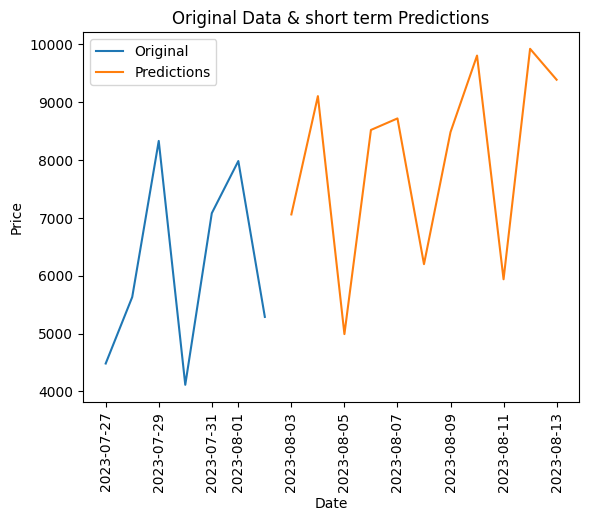

In [ ]:
import matplotlib.pyplot as plt

# Plot the original data
plt.plot(df['Min_Price'], label='Original')

# Plot the predictions
plt.plot(predictions, label='Predictions')

plt.xticks(rotation=90)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Original Data & short term Predictions')

plt.legend()
plt.show()

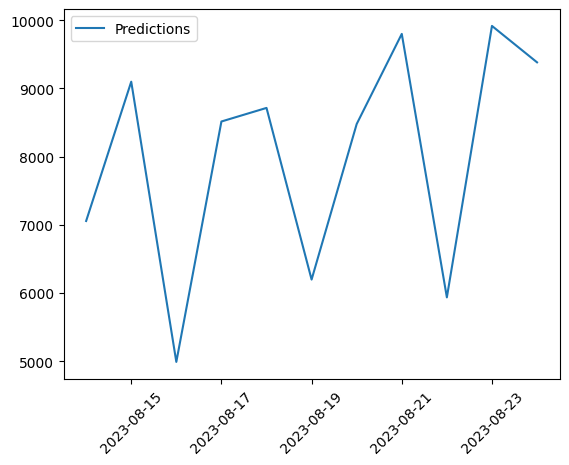

In [ ]:
import matplotlib.pyplot as plt

# Create a date range for predictions
future_dates = pd.date_range(start=df.index[-1] + pd.DateOffset(days=1), periods=len(predictions), freq='D')

# Plot the predictions with future dates
plt.plot(future_dates, predictions, label='Predictions')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [ ]:
print(f"NaN in actual_values: {np.isnan(actual_values).any()}")
print(f"NaN in predictions: {np.isnan(predictions).any()}")
print(f"inf in actual_values: {np.isinf(actual_values).any()}")
print(f"inf in predictions: {np.isinf(predictions).any()}")

NaN in actual_values: False
NaN in predictions: False
inf in actual_values: False
inf in predictions: False


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

actual_values = df['Min_Price'][-(len(predictions)):]
actual_values = np.nan_to_num(actual_values)
predictions = predictions[:len(predictions)]

# MSE
mse = mean_squared_error(actual_values, predictions)

# RMSE
rmse = np.sqrt(mse)

# MAE
mae = mean_absolute_error(actual_values, predictions)

print('MSE:', mse)
print('RMSE:', rmse)
print('MAE:', mae)

MSE: 66702606.73911736
RMSE: 8167.166383704777
MAE: 8007.099835758801
